In [1]:
# Clone your repo
!git clone https://github.com/RiteshGupta-02/chestnut.git
%cd chestnut

Cloning into 'chestnut'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 187 (delta 18), reused 20 (delta 9), pack-reused 158 (from 1)
Receiving objects: 100% (187/187), 334.83 MiB | 39.03 MiB/s, done.
Resolving deltas: 100% (88/88), done.
/kaggle/working/chestnut


In [ ]:
!pip install -q opencv-python-headless
# opencv-python-headless = server version of OpenCV, no display needed
# -q = quiet, less output noise

In [2]:
import torch
import torchvision
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")   # must print True
print(f"GPU name : {torch.cuda.get_device_name(0)}")    # Tesla T4

PyTorch  : 2.10.0+cu128
CUDA available: True
GPU name : Tesla T4


In [3]:
import sys
sys.path.insert(0, "/kaggle/working/chexnet/src")  # so Python finds your modules

# Kaggle paths
DATA_DIR       = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/"
CHECKPOINT_DIR = "/kaggle/working/chestnut/src/checkpoints/"
LOG_DIR        = "/kaggle/working/chestnut/logs/"

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Paths set up ✓")

Paths set up ✓


In [4]:
from src.chestxray_dataset import get_dataloaders
from pathlib import Path

# Small test — batch_size=4, just verify it runs
train_loader, val_loader, test_loader, pos_weights = get_dataloaders(
    data_dir=Path(DATA_DIR),
    batch_size=4,
    num_workers=2,
)

images, labels = next(iter(train_loader))
print(f"Image shape : {images.shape}")    # (4, 3, 224, 224)
print(f"Label shape : {labels.shape}")    # (4, 14)
print(f"pos_weights : {pos_weights.shape}")  # (14,)
print("Data loading ✓")

[Dataset] Loaded 112,120 rows from /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
[Dataset] Class distribution:
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64

[Split] Train: 77,988  |  Val: 8,536  |  Test: 25,596
[Weights] Positive class weights:
  Atelectasis           : 9.5
  Cardiomegaly          : 49.3
  Effusion              : 8.9
  Infiltration          : 5.2
  Mass                  : 20.4
  Nodule                : 17.4
  Pneumonia             : 50.0
  Pneumothorax          : 31.6
  Consolidation         : 29.2
  Edema                 : 50.0
  Emphysema             : 50.0
  Fibrosis              :

In [ ]:
!git pull

In [ ]:
from model import get_model
from train import get_optimizer, get_criterion, train_one_epoch, evaluate, save_checkpoint
from pathlib import Path
import torch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Full training settings
train_loader, val_loader, test_loader, pos_weights = get_dataloaders(
    data_dir=Path(DATA_DIR),
    batch_size=32,       # T4 can handle 32 comfortably
    num_workers=4,       # parallel data loading
)

model     = get_model(num_classes=14, device=device)
optimizer = get_optimizer(model)
criterion = get_criterion(pos_weights, device)

# Learning rate scheduler — reduces lr when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.1
)

best_val_loss   = float('inf')
patience_count  = 0
EARLY_STOP      = 5
EPOCHS          = 10


for epoch in range(1, EPOCHS + 1):
    try:
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
        val_loss   = evaluate(model, val_loader, criterion, device, epoch)
        scheduler.step(val_loss)
    
        print(f"Epoch {epoch}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")
    
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            save_checkpoint(model, epoch, val_loss, CHECKPOINT_DIR)
            print(f"  ✓ New best saved (val_loss: {val_loss:.4f})")
        else:
            patience_count += 1
            print(f"  No improvement ({patience_count}/{EARLY_STOP})")
            if patience_count >= EARLY_STOP:
                print("Early stopping triggered.")
                break
    except Exception as e:
        print(e)
        continue

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

# evaluation part

In [2]:
%cd chestnut

[Errno 2] No such file or directory: 'chestnut'
/kaggle/working/chestnut


In [3]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 354 bytes | 354.00 KiB/s, done.
From https://github.com/RiteshGupta-02/chestnut
   375d016..4fec6fd  main       -> origin/main
Updating 375d016..4fec6fd
Fast-forward
 src/evaluate.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [28]:
from evaluate import evaluate_full, plot_roc_curves, print_auroc_table
from model import get_model
from chestxray_dataset import get_dataloaders
from pathlib import Path
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best checkpoint
model = get_model(num_classes=14, device=device)
ckpt  = torch.load("/kaggle/working/chestnut/src/checkpoint/checkpoint_epoch8.tar",
                    map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded epoch {ckpt['epoch']} | val_loss {ckpt['val_loss']:.4f}")

# Test loader only
_, _, test_loader, _ = get_dataloaders(
    data_dir=Path("/kaggle/input/datasets/organizations/nih-chest-xrays/data"),
    batch_size=32,
    num_workers=4,
)

# Run full evaluation — this prints the AUROC table
# all_labels, all_preds, result, save_path = evaluate_full(
#     model=model,
#     test_loader=test_loader,
#     device=device,
#     result_path="/kaggle/working/results"
# )

Loaded epoch 8 | val_loss 0.8511
[Dataset] Loaded 112,120 rows from /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
[Dataset] Class distribution:
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64

[Split] Train: 77,988  |  Val: 8,536  |  Test: 25,596
[Weights] Positive class weights:
  Atelectasis           : 9.5
  Cardiomegaly          : 49.3
  Effusion              : 8.9
  Infiltration          : 5.2
  Mass                  : 20.4
  Nodule                : 17.4
  Pneumonia             : 50.0
  Pneumothorax          : 31.6
  Consolidation         : 29.2
  Edema                 : 50.0
  Emphysema            

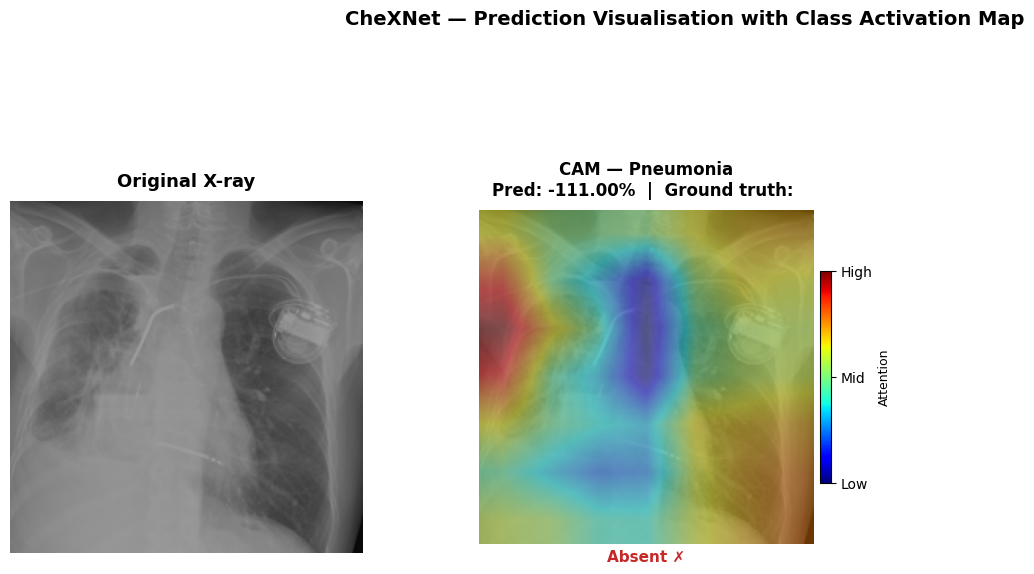

In [32]:
from cam import load_single_image, visualize_prediction
import os

# Pick any test image
sample_image_path = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000003_000.png"
image,label = next(iter(test_loader))
image_tensor = load_single_image(sample_image_path)
dummy_label  = [0] * 14   # replace with real labels if you have them
fig = visualize_prediction(
    model=model,
    image_tensor=image[25],
    true_labels=label[25],
    device=device,
    target_class_idx=6,    # Pneumonia
    save_path="/kaggle/working/results/cam_sample.png"
)

In [29]:
image,label = next(iter(test_loader))

In [30]:
label

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0.],
        [0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0